<a href="https://colab.research.google.com/github/Svasvil/PracticasBigData/blob/Practica%235/SebastianVasquezVillaplana_SC707_Practica5_6_LN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prácticas 05-06  (5%, 5%) Entrega Lección Semana 9, 17:30 horas
## Entrega grupal

# Predicción de la calidad del vino.

El ejercicio descrito a continuación será desarrollado a lo largo de varias prácticas. En este documento se enunciarán las actividades correspondientes a las prácticas 5 y 6.

## Propósito del ejercicio:

Aplicar técnicas de aprendizaje automático para predecir la calidad del vino en base a sus características químicas. Este es un problema de regresión, donde la variable objetivo (quality) es continua. Para lograrlo, se realizará un análisis exploratorio, se prepararán (preprocesarán) los datos para el entrenamiento, se entrenarán modelos para seleccionar el de mejor rendimiento, se afinará el modelo seleccionado y finalmente este se evaluará usando el conjunto de prueba.

## Propósito de las prácticas 5 y 6
Explorar y preprocesar el data set.

## Actividades

1. Análisis exploratorio inicial:
    1. Distribuciones y relaciones: Utilizar tablas de frecuencias, resúmenes numéricos, resúmenes gráficos (Histogramas, Box-plots) para analizar la distribución de cada característica. Buscar posibles correlaciones. Identificar posibles atributos que deban ser considerados en la estratificación de los conjuntos de entrenamiento y prueba. Identificar valores extremos.
1. Separación de datos: Dividir el dataset en conjuntos de entrenamiento y prueba, si se aplica estratificación compárelos con los conjuntos que resultarían al dividirlos solo de forma aleatoria.
1. Preprocesamiento del conjunto de entrenamiento:
    1. Manejo de valores faltantes: Revisar si hay valores faltantes y aplicar una estrategia para manejarlos (por ejemplo, eliminación o imputación).
    1. Escalado: Usar técnicas de escalado (como normalización o estandarización) para escalar los datos numéricos y mejorar el desempeño de algunos modelos.
    1. Codificación de datos categóricas: Utilizar One-Hot Encoding para variables con categorías.
    1. Creación de nuevas características: Revisar la utilidad de generar nuevas variables.
2. Automatización del preprocesamiento: Usar "pipelines" y transformadores para automatizar los pasos del preprocesamiento del conjunto de entrenamiento   


## Descripción del Dataset:

En estas prácticas se utilizará el dataset de vinos (Wine Quality Dataset), que contiene información sobre diversas características químicas de los vinos y su calidad. El objetivo es predecir la calidad del vino utilizando las características proporcionadas. El dataset se compone de dos tipos de vino: vino rojo y vino blanco.

**Características del Dataset:**

El dataset contiene 12 variables, de las cuales 11 son características o atributos (variables predictoras) y una es la variable objetivo (la calidad del vino). Las variables se describen a continuación:

- Variables predictoras
    - fixed acidity: Acidez fija del vino (valor numérico).
    - volatile acidity: Acidez volátil del vino (valor numérico).
    - citric acid: Cantidad de ácido cítrico en el vino (valor numérico).
    - residual sugar: Cantidad de azúcar residual en el vino (valor numérico).
    - chlorides: Nivel de cloruros en el vino (valor numérico).
    - free sulfur dioxide: Cantidad de dióxido de azufre libre (valor numérico).
    - total sulfur dioxide: Cantidad total de dióxido de azufre (valor numérico).
    - density: Densidad del vino (valor numérico).
    - pH: pH del vino (valor numérico).
    - sulphates: Nivel de sulfatos en el vino (valor numérico).
    - alcohol: Porcentaje de alcohol en el vino (valor numérico).

- Variable Objetivo:
    - quality: Calidad del vino medida en una escala del 0 al 10, siendo 0 la menor calidad y 10 la mayor. Esta es la variable que se debe predecir utilizando los datos proporcionados.

El data set está separado en dos archivos (uno para vino rojo y otro para vino blanco). Únalos en un solo archivo y agregue una columna categórica para identificar el tipo de vino con los siguientes valores: "Blanco" y "Rojo".

Borre aleatoriamente algunos valores en las columnas de algunos registros para generar nulos.

Referencia del data set:
P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis.
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.


### En próximas prácticas .....
Usando el pipeline de preprocesamiento se entrenarán varios modelos, se seleccionará, se afinará y se probará el mejor.

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


Tipo_Vino
Blanco    4898
Rojo      1599
Name: count, dtype: int64


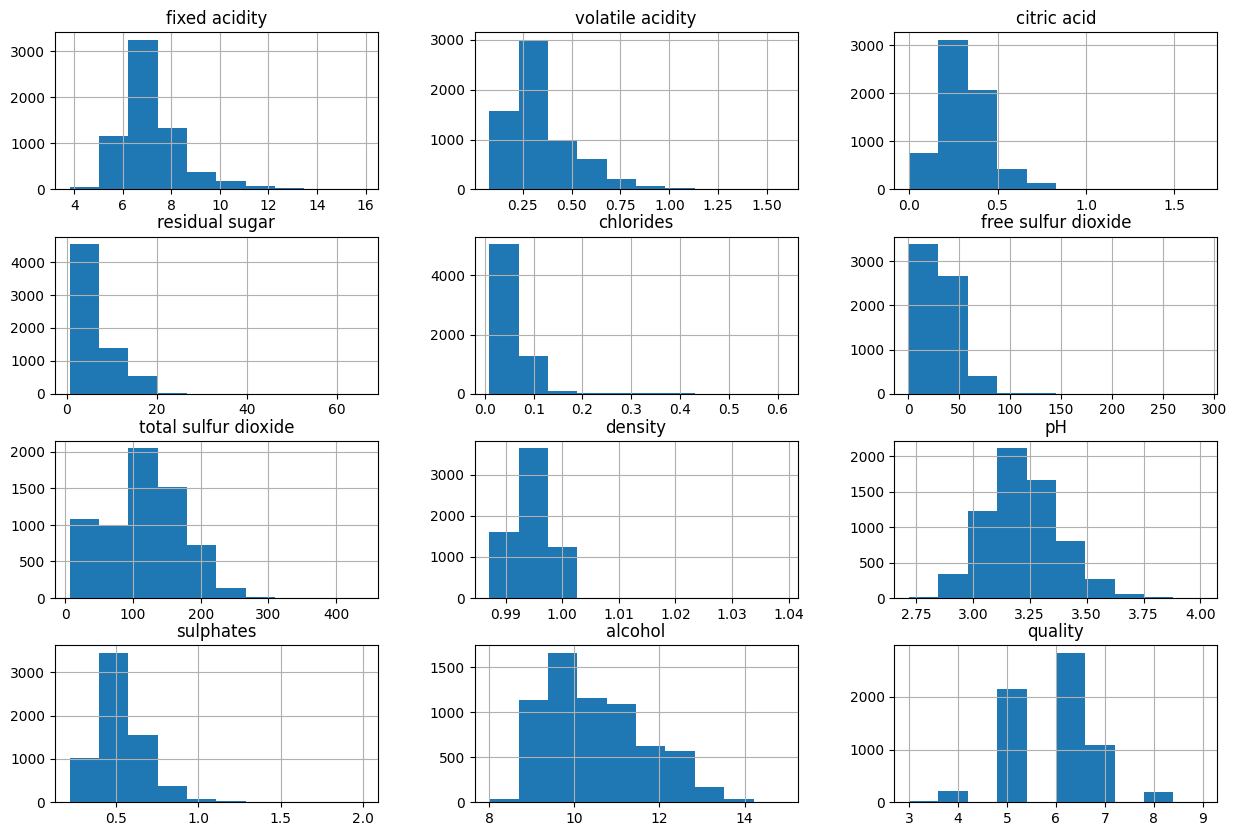

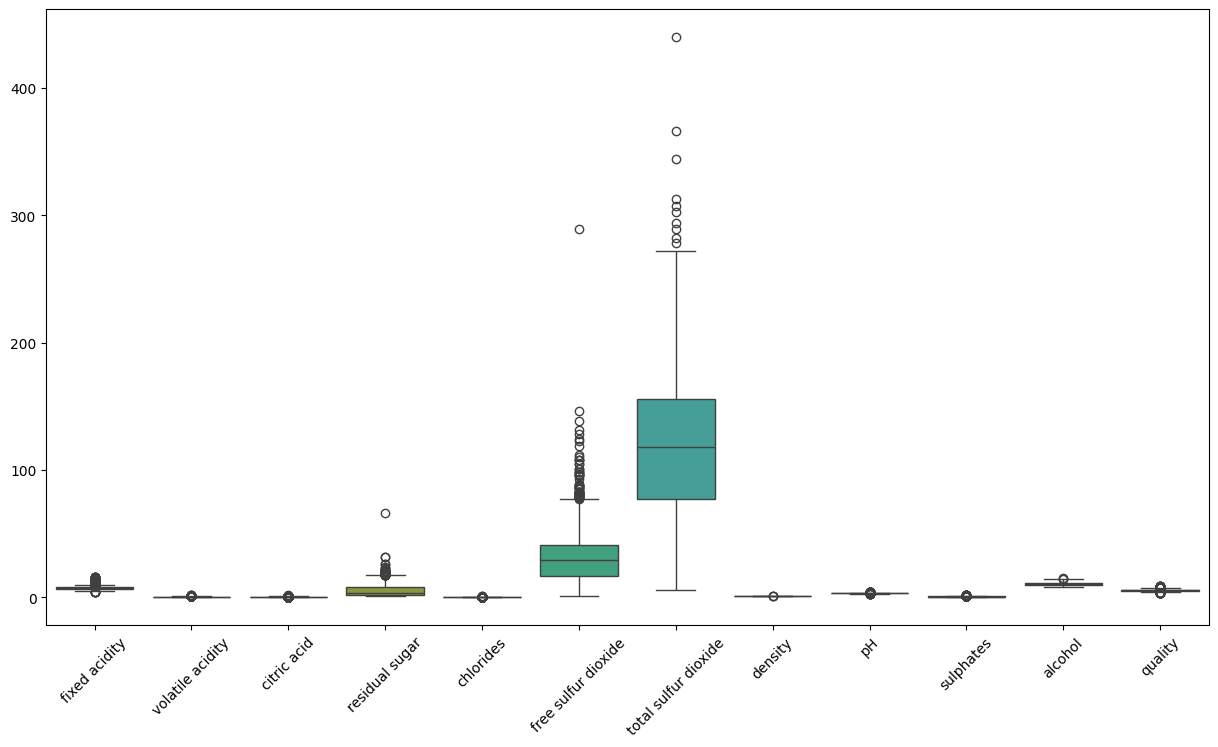

'Datos vino Blanco \n'

Tamano de entreno: 3917
Tamano de test: 980


'Datos vino Rojo \n'

Tamano de entreno: 1278
Tamano de test: 320


'Datos Vinos Combinados'

Tamaño de Entrenamiento: 5197
Tamaño de Prueba: 1300


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split # Esta es la libreria que usamos para hacer los traingn sets
#1.
dt_rojo = pd.read_csv("/content/winequality-red.csv", sep=';')
dt_blanco = pd.read_csv("/content/winequality-white.csv", sep=';')

display(Dataframe.dtypes)

dt_rojo['Tipo_Vino'] = 'Rojo'# le agregamos una nueva coluimna
dt_blanco['Tipo_Vino'] = 'Blanco' # le agregamos una nueva coluimna


Dataframe = pd.concat([dt_rojo, dt_blanco], ignore_index=True) # juntamos ambos dataframes para hacer uno solo
print(Dataframe['Tipo_Vino'].value_counts())

#histograma
Dataframe.hist(figsize=(15, 10))
plt.show()
plt.figure(figsize=(15, 8))
#boxplot
sns.boxplot(data=Dataframe.drop(columns=['Tipo_Vino']))
plt.xticks(rotation=45)
plt.show()



#2.
#training  set para blancos
display("Datos vino Blanco \n")
Doc = pd.read_csv("/content/winequality-white.csv",header =1 )
Datos = Doc.copy()
train_rand, test_rand = train_test_split(
    Datos,
    test_size=0.2,
    random_state=42
)
print(f"Tamano de entreno: {len(train_rand)}") # Estos basicamente son los datos que se usaron para el set completo ,el total de datos
print(f"Tamano de test: {len(test_rand)}") # Y estos son los datos que usaron para la prueba especificamente

#training  set para Rojos
display("Datos vino Rojo \n")
Doc = pd.read_csv("/content/winequality-red.csv",header =1 )
Datos = Doc.copy()
train_rand, test_rand = train_test_split(
    Datos,
    test_size=0.2,
    random_state=42
)
print(f"Tamano de entreno: {len(train_rand)}") # Estos basicamente son los datos que se usaron para el set completo ,el total de datos
print(f"Tamano de test: {len(test_rand)}") # Y estos son los datos que usaron para la prueba especificamente



# #training  set para el dataframe con ambos datos
display('Datos Vinos Combinados')
Datos = Dataframe.copy()
train_rand, test_rand = train_test_split(
    Datos,
    test_size=0.2,
    random_state=42
)

print(f"Tamaño de Entrenamiento: {len(train_rand)}")
print(f"Tamaño de Prueba: {len(test_rand)}")